In [3]:
import tf_keras as keras
from tf_keras import layers
import tensorflow_hub as hub
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from keras.applications import efficientnet
from transformers import pipeline

In [13]:
#모델 가져오기 
hub_effice_base = hub.KerasLayer('https://www.kaggle.com/models/tensorflow/efficientnet/TensorFlow2/b0-feature-vector/1')

In [6]:
#데이터셋 로드 및 트레인셋, 검증셋 분류
train_ds, val_ds = keras.utils.image_dataset_from_directory('Pistachio_Image_Dataset',image_size=(224,224), batch_size=16, 
                                                            validation_split=0.2, subset='both', seed=42)

Found 2150 files belonging to 2 classes.
Using 1720 files for training.
Using 430 files for validation.


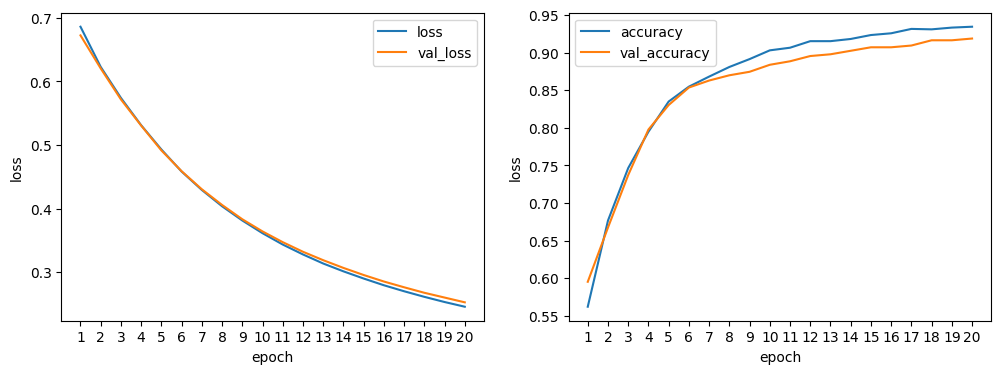

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12,4))
axs[0].plot(range(1, 21), hist.history['loss'], label='loss')
axs[0].plot(range(1, 21), hist.history['val_loss'], label='val_loss')
axs[0].set_xticks(range(1,21))
axs[0].set_xlabel('epoch')
axs[0].set_ylabel('loss')
axs[0].legend()

axs[1].plot(range(1, 21), hist.history['accuracy'], label='accuracy')
axs[1].plot(range(1, 21), hist.history['val_accuracy'], label='val_accuracy')
axs[1].set_xticks(range(1,21))
axs[1].set_xlabel('epoch')
axs[1].set_ylabel('loss')
axs[1].legend()
plt.show()

In [16]:
inputs = keras.Input(shape=(224,224,3))
x = layers.Rescaling(1.0/255.0) (inputs)
x = hub_effice_base (x)
x = layers.Dense(128, activation='relu') (x)
outputs = layers.Dense(1, activation='sigmoid') (x)
model2 = keras.Model(inputs, outputs)
rmsprop = keras.optimizers.RMSprop( learning_rate=1e-4 )
model2.compile(optimizer=rmsprop, loss='binary_crossentropy', metrics=['accuracy'])

#모델 학습
hist = model2.fit( train_ds, epochs=20, validation_data=val_ds )

Epoch 1/20
108/108 [==============================] - 7s 47ms/step - loss: 0.4121 - accuracy: 0.8459 - val_loss: 0.2572 - val_accuracy: 0.9279
Epoch 2/20
108/108 [==============================] - 5s 43ms/step - loss: 0.2064 - accuracy: 0.9477 - val_loss: 0.1730 - val_accuracy: 0.9442
Epoch 3/20
108/108 [==============================] - 5s 43ms/step - loss: 0.1454 - accuracy: 0.9616 - val_loss: 0.1364 - val_accuracy: 0.9558
Epoch 4/20
108/108 [==============================] - 5s 42ms/step - loss: 0.1142 - accuracy: 0.9674 - val_loss: 0.1120 - val_accuracy: 0.9651
Epoch 5/20
108/108 [==============================] - 5s 42ms/step - loss: 0.0955 - accuracy: 0.9721 - val_loss: 0.0932 - val_accuracy: 0.9721
Epoch 6/20
108/108 [==============================] - 7s 66ms/step - loss: 0.0818 - accuracy: 0.9744 - val_loss: 0.0844 - val_accuracy: 0.9651
Epoch 7/20
108/108 [==============================] - 3s 32ms/step - loss: 0.0725 - accuracy: 0.9808 - val_loss: 0.0767 - val_accuracy: 0.9721

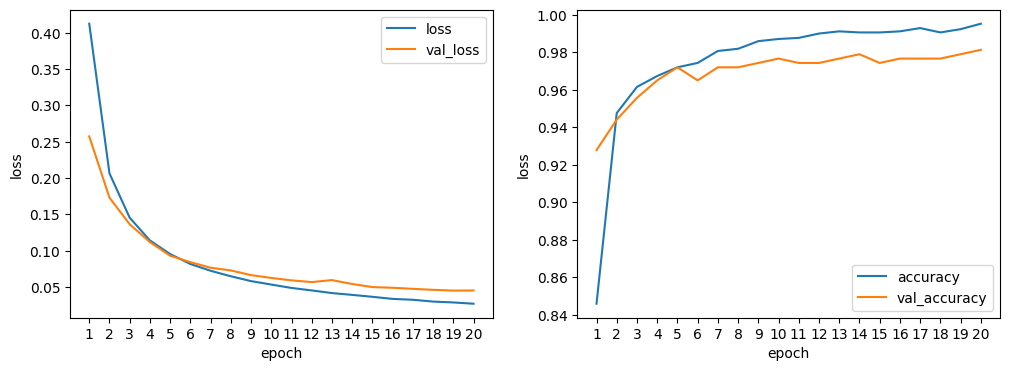

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(12,4))
axs[0].plot(range(1, 21), hist.history['loss'], label='loss')
axs[0].plot(range(1, 21), hist.history['val_loss'], label='val_loss')
axs[0].set_xticks(range(1,21))
axs[0].set_xlabel('epoch')
axs[0].set_ylabel('loss')
axs[0].legend()

axs[1].plot(range(1, 21), hist.history['accuracy'], label='accuracy')
axs[1].plot(range(1, 21), hist.history['val_accuracy'], label='val_accuracy')
axs[1].set_xticks(range(1,21))
axs[1].set_xlabel('epoch')
axs[1].set_ylabel('loss')
axs[1].legend()
plt.show()